# Feature Selection and Deduplication

**Chapter 8: Feature Engineering**
**Section Reference**: 8.6 — Combining Features and Controlling Search

**Docker image**: `ml4t`

## Purpose

A feature engineering pipeline produces many candidates — different lookbacks,
transforms, and interaction variants. This notebook demonstrates how to reduce
that set to a focused, production-ready collection using systematic selection
and deduplication.

## Learning Objectives

1. Compute cross-sectional IC and rank features by predictive power
2. Apply correlation filtering to remove redundant features
3. Cluster near-duplicate features and select representatives
4. Use Benjamini–Hochberg FDR to control false discovery across multiple tests
5. Assess feature stability via bootstrap IC
6. Compare IC-based and ML-based (LightGBM) importance rankings

## Prerequisites

- Run [`03_financial_features`](../case_studies/etfs/03_financial_features.ipynb)
  to produce `financial.parquet`
- Requires `ml4t-diagnostic` and `ml4t-engineer` libraries

## References

- Harvey, Liu, and Zhu (2016) — Multiple testing in factor research
- Meinshausen and Bühlmann (2010) — Stability selection

**Output**: Selected feature list for downstream Chapter 9 use

## Setup

In [1]:
"""Feature Selection and Deduplication — reduce feature candidates to a focused production-ready set."""

import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
import statsmodels.api as sm
from ml4t.diagnostic.metrics import pooled_ic
from scipy.cluster.hierarchy import fcluster, leaves_list, linkage
from scipy.spatial.distance import squareform

warnings.filterwarnings("ignore")

from data import load_etfs
from utils.paths import get_case_study_dir, get_output_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

In [2]:
START_DATE = "2006-01-01"
N_BOOTSTRAP = 50
MAX_SYMBOLS = 0
SEED = 42

In [3]:
set_global_seeds(SEED)

## 1. Load Features from ETF Case Study

The ETF case study produced features in `case_studies/etfs/features/`.

In [4]:
CASE_DIR = get_case_study_dir("etfs")
FEATURES_PATH = CASE_DIR / "features" / "financial.parquet"

if not FEATURES_PATH.exists():
    raise FileNotFoundError(
        f"Features file not found at {FEATURES_PATH}. "
        "Please run case_studies/etfs/03_financial_features.py first."
    )

features_df = pl.read_parquet(FEATURES_PATH)
prices_df = load_etfs()

# Apply date filter
features_df = features_df.filter(pl.col("timestamp") >= pl.lit(START_DATE).str.to_date())
prices_df = prices_df.filter(pl.col("timestamp") >= pl.lit(START_DATE).str.to_date())

if MAX_SYMBOLS > 0:
    top_symbols = (
        features_df.group_by("symbol")
        .len()
        .sort("len", descending=True)
        .head(MAX_SYMBOLS)["symbol"]
    )
    features_df = features_df.filter(pl.col("symbol").is_in(top_symbols))
    prices_df = prices_df.filter(pl.col("symbol").is_in(top_symbols))

# Compute forward returns on-demand
labels_df = (
    prices_df.sort(["symbol", "timestamp"])
    .with_columns(
        (pl.col("close").shift(-21).over("symbol") / pl.col("close") - 1).alias("fwd_return_1m")
    )
    .select(["timestamp", "symbol", "fwd_return_1m"])
    .drop_nulls()
)

print(f"Features: {features_df.shape}")
print(f"Labels: {labels_df.shape}")

Features: (396186, 59)
Labels: (468562, 3)


In [5]:
all_feature_cols = [c for c in features_df.columns if c not in ["timestamp", "symbol"]]
print(f"Available features: {len(all_feature_cols)}")
for i, col in enumerate(all_feature_cols, 1):
    print(f"  {i:2d}. {col}")

Available features: 57
   1. ret_5d
   2. ret_10d
   3. ret_21d
   4. ret_42d
   5. ret_63d
   6. ret_126d
   7. ret_189d
   8. ret_252d
   9. skip_recent_12_1
  10. skip_recent_6_1
  11. vol_21d
  12. vol_63d
  13. vol_126d
  14. vol_252d
  15. sharpe_5d
  16. sharpe_10d
  17. sharpe_21d
  18. sharpe_42d
  19. sharpe_63d
  20. sharpe_126d
  21. sharpe_189d
  22. sharpe_252d
  23. mom_accel_short
  24. mom_accel_medium
  25. mom_accel_long
  26. vol_ratio_short
  27. vol_ratio_medium
  28. rsi_7
  29. rsi_14
  30. macd_line
  31. adx_14
  32. cci_14
  33. cci_21
  34. stoch_k
  35. aroon_diff
  36. sma_ratio_50
  37. sma_ratio_200
  38. ema_ratio_26
  39. bb_pctb_20
  40. natr_14
  41. chop_14
  42. hurst_100
  43. max_dd_63d
  44. max_dd_126d
  45. vol_ratio_21d
  46. vol_ratio_63d
  47. obv_zscore_63d
  48. pct_positive_63d
  49. dist_52w_high
  50. dist_52w_low
  51. corr_spy_tlt_63d
  52. ret_126d_rank
  53. sharpe_126d_rank
  54. vol_63d_rank
  55. regime
  56. yield_curve_slope
 

## 2. Compute Information Coefficient (IC)

IC measures the Spearman rank correlation between features and forward returns.
We compute IC **cross-sectionally** (per date, then average). Pooled IC
conflates time-series drift with cross-sectional predictive power.

In [6]:
# Merge features with forward returns
analysis = features_df.join(
    labels_df.select(["timestamp", "symbol", "fwd_return_1m"]),
    on=["timestamp", "symbol"],
    how="inner",
).drop_nulls(subset=["fwd_return_1m"])

print(f"Analysis dataset: {analysis.shape}")

Analysis dataset: (394233, 60)


In [7]:
# Compute cross-sectional IC per date
ic_by_date = analysis.group_by("timestamp").agg(
    [pl.corr(col, "fwd_return_1m", method="spearman").alias(col) for col in all_feature_cols]
)

# Summary statistics. The daily IC series is serially correlated (overlapping
# information sets, slow-moving common factors). We report both the i.i.d.
# t-stat and a Newey-West HAC t-stat from regressing the IC time series on a
# constant. HAC is the headline used for the BH-FDR step in §5.
NW_MAXLAGS = 12
ic_results = {}
for col in all_feature_cols:
    daily_ics = ic_by_date[col].drop_nulls().to_numpy()
    if len(daily_ics) < 10:
        ic_results[col] = {"ic": np.nan, "n": len(daily_ics)}
        continue

    mean_ic = np.mean(daily_ics)
    std_ic = np.std(daily_ics, ddof=1)
    # Yield NaN on both branches when std_ic == 0 so the iid and HAC outputs
    # are internally consistent for degenerate series.
    if std_ic > 0:
        t_stat_iid = mean_ic / (std_ic / np.sqrt(len(daily_ics)))
        nw = sm.OLS(daily_ics, np.ones(len(daily_ics))).fit(
            cov_type="HAC", cov_kwds={"maxlags": NW_MAXLAGS}
        )
        t_stat_nw = float(nw.tvalues[0])
    else:
        t_stat_iid = np.nan
        t_stat_nw = np.nan
    ic_results[col] = {
        "ic": mean_ic,
        "ic_std": std_ic,
        "t_stat_iid": t_stat_iid,
        "t_stat_NW": t_stat_nw,
        "n": len(daily_ics),
    }

ic_df = (
    pl.DataFrame(
        [
            {
                "feature": k,
                "ic": v["ic"],
                "t_stat_iid": v.get("t_stat_iid"),
                "t_stat_NW": v.get("t_stat_NW"),
                "n_obs": v["n"],
            }
            for k, v in ic_results.items()
        ]
    )
    .with_columns(pl.col("ic").abs().alias("ic_abs"))
    .sort("ic_abs", descending=True)
)

print(f"\nFeature IC Rankings (top 15) — Newey-West with {NW_MAXLAGS} lags:")
ic_df.head(15)


Feature IC Rankings (top 15) — Newey-West with 12 lags:


feature,ic,t_stat_iid,t_stat_NW,n_obs,ic_abs
str,f64,f64,f64,i64,f64
"""ret_252d""",NaN,NaN,NaN,4759,NaN
"""skip_recent_12_1""",NaN,NaN,NaN,4759,NaN
"""vol_252d""",NaN,NaN,NaN,4759,NaN
"""sharpe_252d""",NaN,NaN,NaN,4759,NaN
"""mom_accel_long""",NaN,NaN,NaN,4759,NaN
…,…,…,…,…,…
"""natr_14""",0.05722,10.388454,10.353586,4759,0.05722
"""vol_126d""",0.056434,10.029753,9.94651,4759,0.056434
"""vol_63d""",0.05091,9.110108,9.051793,4759,0.05091


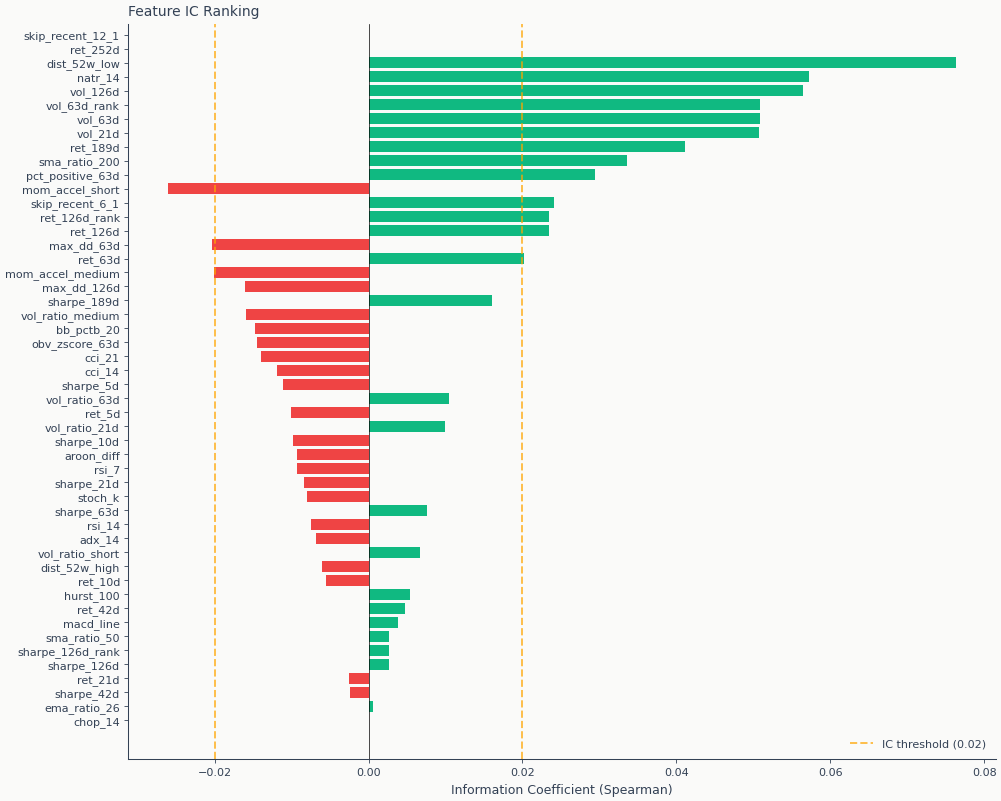

In [8]:
# IC bar chart
fig, ax = plt.subplots(figsize=(10, 8))
ic_pd = ic_df.to_pandas().sort_values("ic_abs", ascending=True)
colors = [COLORS["positive"] if ic > 0 else COLORS["negative"] for ic in ic_pd["ic"]]
ax.barh(ic_pd["feature"], ic_pd["ic"], color=colors)
ax.axvline(0, color="black", linewidth=0.5)
ax.axvline(0.02, color="orange", linestyle="--", alpha=0.7, label="IC threshold (0.02)")
ax.axvline(-0.02, color="orange", linestyle="--", alpha=0.7)
ax.set_xlabel("Information Coefficient (Spearman)")
ax.set_title("Feature IC Ranking")
ax.legend()
plt.show()

## 3. Correlation Filtering

Highly correlated features provide overlapping information. We compute
correlation on the full panel (all dates × symbols), then remove features
with |r| > 0.9 — keeping the one with higher IC in each redundant pair.

In [9]:
feature_matrix = features_df.select(all_feature_cols).drop_nulls()
corr_np = feature_matrix.corr().to_numpy()

print(f"Correlation matrix: {corr_np.shape[0]} × {corr_np.shape[1]} features")

Correlation matrix: 57 × 57 features


### Remove Redundant Features
Greedily drop the weaker member of each highly correlated pair.

In [10]:
def filter_correlated_features(
    corr_matrix: np.ndarray,
    feature_names: list[str],
    ic_scores: dict[str, float] | None = None,
    threshold: float = 0.9,
) -> tuple[list[str], list[str]]:
    """Remove highly correlated features, keeping the one with higher IC."""
    removed = set()
    n = len(feature_names)

    for i in range(n):
        if feature_names[i] in removed:
            continue
        for j in range(i + 1, n):
            if feature_names[j] in removed:
                continue
            if abs(corr_matrix[i, j]) > threshold:
                if ic_scores:
                    ic_i = abs(ic_scores.get(feature_names[i], 0))
                    ic_j = abs(ic_scores.get(feature_names[j], 0))
                    to_remove = feature_names[j] if ic_i >= ic_j else feature_names[i]
                else:
                    to_remove = feature_names[j]
                removed.add(to_remove)

    kept = [f for f in feature_names if f not in removed]
    return kept, list(removed)

In [11]:
ic_scores = {row["feature"]: row["ic"] for row in ic_df.to_dicts()}

kept_after_corr, removed_by_corr = filter_correlated_features(
    corr_matrix=corr_np,
    feature_names=all_feature_cols,
    ic_scores=ic_scores,
    threshold=0.9,
)

print("Correlation Filtering (threshold=0.9):")
print(f"  Before: {len(all_feature_cols)} features")
print(f"  After:  {len(kept_after_corr)} features")
print(f"  Removed: {removed_by_corr}")

Correlation Filtering (threshold=0.9):
  Before: 57 features
  After:  43 features
  Removed: ['rsi_14', 'cci_14', 'vol_ratio_21d', 'sma_ratio_50', 'vol_126d', 'stoch_k', 'vol_63d', 'rsi_7', 'cci_21', 'ret_252d', 'sharpe_189d', 'ret_126d', 'max_dd_126d', 'vol_21d']


## 4. Clustering and Deduplication

Even after removing pairs above 0.9, many features remain near-duplicates.
Hierarchical clustering groups similar features so we can pick one
representative per cluster — preserving diversity across families while
removing redundancy within them.

**Linkage choice**: We use **average linkage** (not Ward) because Ward
assumes Euclidean distance. Correlation-based distances don't satisfy
this assumption; average and complete linkage work with any distance.

In [12]:
# Build correlation matrix for surviving features
surv_idx = [all_feature_cols.index(f) for f in kept_after_corr]
surv_corr = corr_np[np.ix_(surv_idx, surv_idx)]

# Distance = 1 - |ρ| (NaN correlations treated as uncorrelated → distance 1.0)
dist_matrix = 1 - np.abs(np.nan_to_num(surv_corr, nan=0.0))
np.fill_diagonal(dist_matrix, 0)
dist_matrix = (dist_matrix + dist_matrix.T) / 2
dist_matrix = np.clip(dist_matrix, 0, 2)

dist_condensed = squareform(dist_matrix, checks=False)
link = linkage(dist_condensed, method="average")

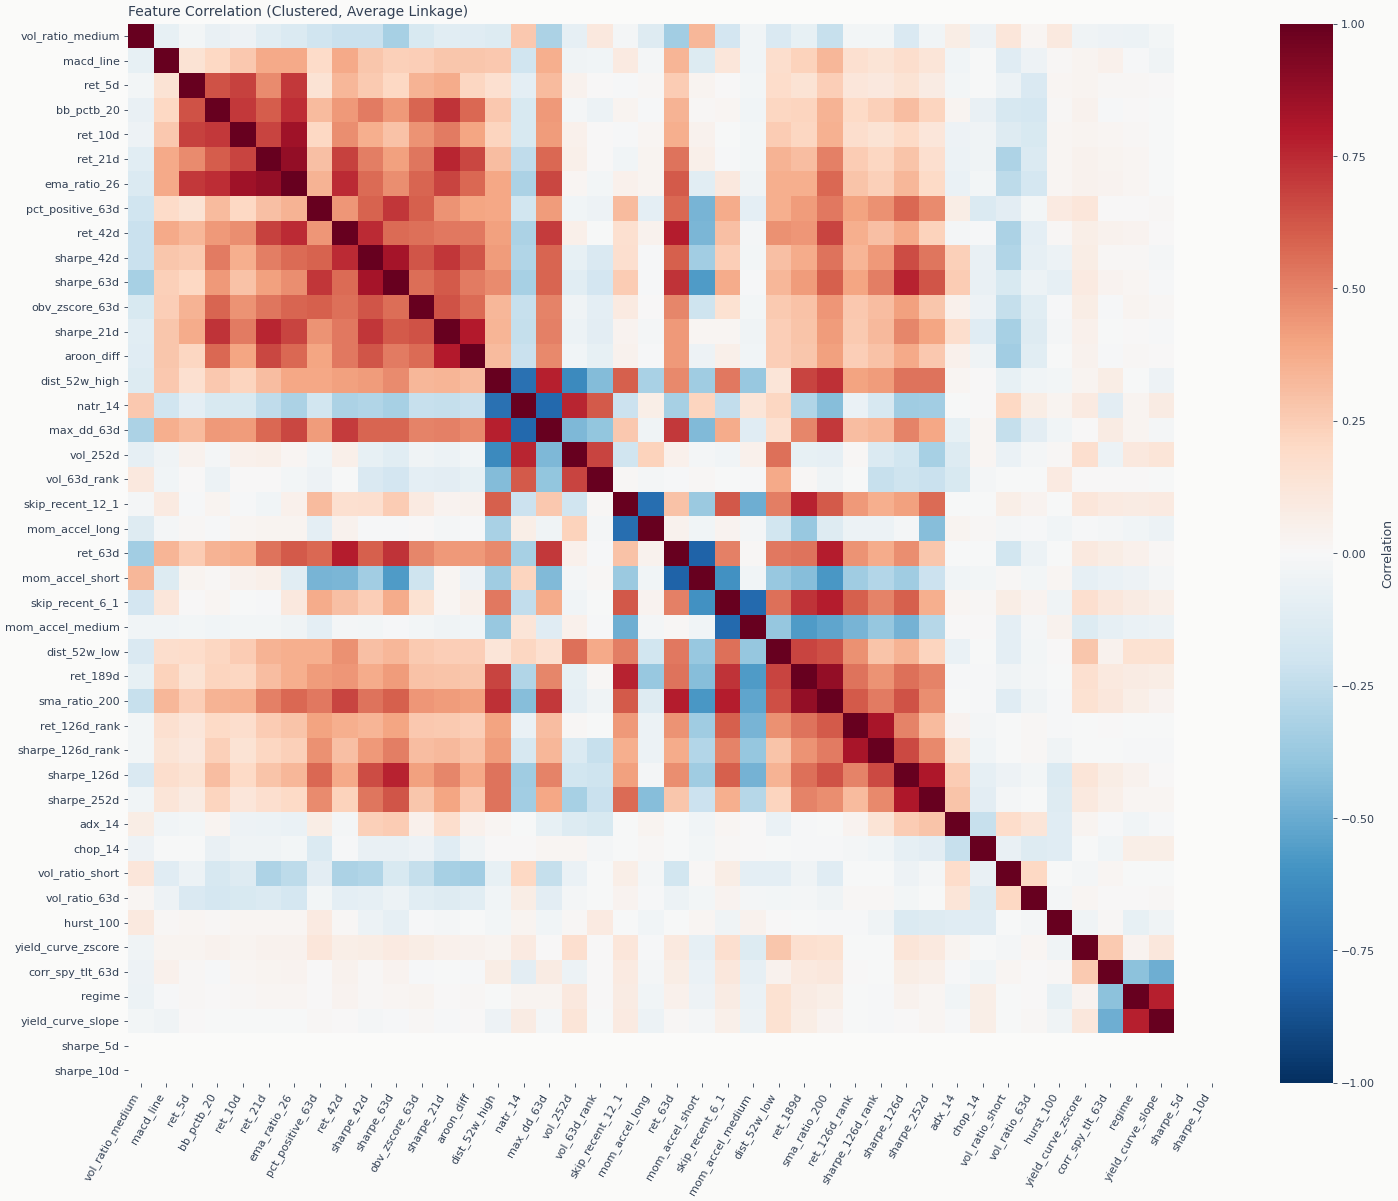

In [13]:
# Clustered heatmap
leaves = leaves_list(link)
reordered_names = [kept_after_corr[i] for i in leaves]
reordered_corr = surv_corr[np.ix_(leaves, leaves)]

fig, ax = plt.subplots(figsize=(14, 12))
n_feats = len(reordered_names)
sns.heatmap(
    reordered_corr,
    annot=(n_feats <= 25),
    fmt=".2f",
    annot_kws={"size": 6},
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    xticklabels=reordered_names,
    yticklabels=reordered_names,
    cbar_kws={"label": "Correlation"},
)
ax.set_title("Feature Correlation (Clustered, Average Linkage)")
ax.tick_params(axis="both", labelsize=8)
plt.setp(ax.get_xticklabels(), rotation=60, ha="right")
plt.show()

The block structure reveals which features are essentially measuring the
same thing. Within each block, correlations are high (>0.7), confirming
that one representative per cluster is sufficient. Between blocks,
correlations are low — genuine diversification.

In [14]:
# Assign clusters and select representatives by highest |IC|
N_CLUSTERS = 5
clusters = fcluster(link, N_CLUSTERS, criterion="maxclust")

print(f"\n=== Factor Clusters ({N_CLUSTERS} groups) ===\n")
representatives = []

for c in range(1, N_CLUSTERS + 1):
    cluster_factors = [kept_after_corr[i] for i, clust in enumerate(clusters) if clust == c]
    best = max(cluster_factors, key=lambda f: abs(ic_scores.get(f, 0)))
    representatives.append(best)

    print(f"Cluster {c}:")
    for f in cluster_factors:
        marker = "  →" if f == best else "   "
        print(f"  {marker} {f}: IC = {ic_scores.get(f, 0):.4f}")

print(f"\nRepresentatives: {representatives}")


=== Factor Clusters (5 groups) ===

Cluster 1:
      ret_5d: IC = -0.0101
      ret_10d: IC = -0.0055
      ret_21d: IC = -0.0025
      ret_42d: IC = 0.0047
      ret_63d: IC = 0.0201
      ret_189d: IC = 0.0411
      skip_recent_12_1: IC = nan
      skip_recent_6_1: IC = 0.0241
      vol_252d: IC = nan
      sharpe_21d: IC = -0.0083
      sharpe_42d: IC = -0.0024
      sharpe_63d: IC = 0.0076
      sharpe_126d: IC = 0.0026
      sharpe_252d: IC = nan
      mom_accel_short: IC = -0.0261
      mom_accel_medium: IC = -0.0200
      mom_accel_long: IC = nan
      vol_ratio_short: IC = 0.0067
      vol_ratio_medium: IC = -0.0159
      macd_line: IC = 0.0038
      adx_14: IC = -0.0068
      aroon_diff: IC = -0.0093
      sma_ratio_200: IC = 0.0335
      ema_ratio_26: IC = 0.0005
      bb_pctb_20: IC = -0.0147
      natr_14: IC = 0.0572
      chop_14: IC = 0.0000
      max_dd_63d: IC = -0.0203
      vol_ratio_63d: IC = 0.0105
      obv_zscore_63d: IC = -0.0145
      pct_positive_63d: IC = 0.

## 5. Multiple Testing Correction (BH-FDR)

With many features tested, some appear significant by chance.
Benjamini–Hochberg FDR controls the expected false discovery rate.

**Inference**: the p-values fed into BH-FDR come from the **Newey-West HAC**
t-statistic on each feature's daily IC series (matching the table above and
the headline measure in `06_robustness_sensitivity.py`). The i.i.d. t-stat
would overstate significance because daily ICs share slow-moving common
factors and overlapping information sets.

In [15]:
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr

ic_pvalues = []
ic_feature_names = []
for col in all_feature_cols:
    daily_ics = ic_by_date[col].drop_nulls().to_numpy()
    # Exclude degenerate series (constant or non-finite) so they do not
    # contribute NaN p-values, which would still inflate BH's denominator and
    # tighten the per-rank threshold for every valid feature. Mirror the same
    # std_ic > 0 guard the IC-ranking loop above uses.
    if len(daily_ics) < 20 or np.std(daily_ics, ddof=1) == 0 or not np.isfinite(daily_ics).all():
        continue
    nw = sm.OLS(daily_ics, np.ones(len(daily_ics))).fit(
        cov_type="HAC", cov_kwds={"maxlags": NW_MAXLAGS}
    )
    p_val = float(nw.pvalues[0])
    if not np.isfinite(p_val):
        continue
    ic_pvalues.append(p_val)
    ic_feature_names.append(col)

if ic_pvalues:
    bh_result = benjamini_hochberg_fdr(ic_pvalues, alpha=0.05, return_details=True)

    n_significant_raw = sum(p < 0.05 for p in ic_pvalues)
    n_significant_fdr = sum(bh_result["rejected"])

    print(f"Features tested:                 {len(ic_pvalues)}")
    print(f"Significant at p<0.05 (raw):     {n_significant_raw}")
    print(f"Significant after BH-FDR:        {n_significant_fdr}")
    print(f"False discoveries prevented:     {n_significant_raw - n_significant_fdr}")

    survivors = [ic_feature_names[i] for i, r in enumerate(bh_result["rejected"]) if r]
    if survivors:
        print("\nFeatures surviving FDR correction:")
        for f in survivors:
            print(f"  - {f}")

Features tested:                 48
Significant at p<0.05 (raw):     31
Significant after BH-FDR:        29
False discoveries prevented:     2

Features surviving FDR correction:
  - ret_63d
  - ret_126d
  - ret_189d
  - skip_recent_6_1
  - vol_21d
  - vol_63d
  - vol_126d
  - sharpe_5d
  - sharpe_10d
  - sharpe_189d
  - mom_accel_short
  - mom_accel_medium
  - vol_ratio_medium
  - rsi_7
  - cci_14
  - cci_21
  - aroon_diff
  - sma_ratio_200
  - bb_pctb_20
  - natr_14
  - max_dd_63d
  - max_dd_126d
  - vol_ratio_21d
  - vol_ratio_63d
  - obv_zscore_63d
  - pct_positive_63d
  - dist_52w_low
  - ret_126d_rank
  - vol_63d_rank


## 6. Selection Pipeline

Applying the filters in sequence: correlation filtering → IC filtering →
top-K selection.

In [16]:
# IC filtering
IC_THRESHOLD = 0.01
kept_after_ic = [f for f in kept_after_corr if abs(ic_scores.get(f, 0)) >= IC_THRESHOLD]

print(f"IC Filtering (|IC| >= {IC_THRESHOLD}):")
print(f"  Before: {len(kept_after_corr)} features")
print(f"  After:  {len(kept_after_ic)} features")

IC Filtering (|IC| >= 0.01):
  Before: 43 features
  After:  18 features


In [17]:
# Top-K selection
TOP_K = 10
ic_ranked = sorted(kept_after_ic, key=lambda f: abs(ic_scores.get(f, 0)), reverse=True)
final_features = ic_ranked[:TOP_K]

print(f"\nTop-{TOP_K} Selected Features:")
for i, f in enumerate(final_features, 1):
    print(f"  {i:2d}. {f} (IC={ic_scores[f]:.4f})")


Top-10 Selected Features:
   1. dist_52w_low (IC=0.0764)
   2. natr_14 (IC=0.0572)
   3. vol_63d_rank (IC=0.0509)
   4. ret_189d (IC=0.0411)
   5. sma_ratio_200 (IC=0.0335)
   6. pct_positive_63d (IC=0.0294)
   7. mom_accel_short (IC=-0.0261)
   8. skip_recent_6_1 (IC=0.0241)
   9. ret_126d_rank (IC=0.0234)
  10. max_dd_63d (IC=-0.0203)


## 7. Stability Selection via Bootstrap IC

Stability selection tests whether features remain important across bootstrap
samples. Features that rank highly in >80% of samples are considered stable.

> **Caveat**: The bootstrap below samples individual rows (date × symbol),
> pooling across dates. A more rigorous approach bootstraps by *date*
> (block bootstrap), preserving cross-sectional structure. The pooled
> version here is a quick filter; production systems should use
> time-aware resampling.

In [18]:
def bootstrap_ic(
    df: pl.DataFrame,
    feature_cols: list[str],
    return_col: str = "fwd_return_1m",
    n_bootstrap: int = 50,
    sample_frac: float = 0.8,
) -> pl.DataFrame:
    """Compute IC across bootstrap samples to assess stability.

    Uses the global numpy seed set in the preamble via ``set_global_seeds(SEED)``.
    """
    n_samples = len(df)
    sample_size = int(n_samples * sample_frac)

    results = {f: [] for f in feature_cols}

    for _ in range(n_bootstrap):
        indices = np.random.choice(n_samples, size=sample_size, replace=True)
        sample = df[indices.tolist()]
        y = sample[return_col].to_numpy()

        for col in feature_cols:
            x = sample[col].to_numpy()
            mask = np.isfinite(x) & np.isfinite(y)
            if mask.sum() < 30:
                results[col].append(np.nan)
                continue
            ic = pooled_ic(x[mask], y[mask])
            results[col].append(ic)

    stability_data = []
    for col in feature_cols:
        ics = np.array(results[col])
        valid = ics[~np.isnan(ics)]
        if len(valid) == 0:
            continue
        stability_data.append(
            {
                "feature": col,
                "ic_mean": np.mean(valid),
                "ic_std": np.std(valid),
                "ic_ir": np.mean(valid) / (np.std(valid) + 1e-8),
                "positive_pct": np.mean(valid > 0) * 100,
            }
        )

    if not stability_data:
        return pl.DataFrame(
            {"feature": [], "ic_mean": [], "ic_std": [], "ic_ir": [], "positive_pct": []}
        )
    return pl.DataFrame(stability_data).sort("ic_ir", descending=True)

In [19]:
stability = bootstrap_ic(df=analysis, feature_cols=final_features, n_bootstrap=N_BOOTSTRAP)
print(f"Stability Selection ({N_BOOTSTRAP} bootstrap samples):")
stability

Stability Selection (50 bootstrap samples):


feature,ic_mean,ic_std,ic_ir,positive_pct
str,f64,f64,f64,f64
"""natr_14""",0.112569,0.001795,62.698844,100.0
"""dist_52w_low""",0.074668,0.001652,45.188178,100.0
"""vol_63d_rank""",0.047153,0.001877,25.117785,100.0
"""ret_126d_rank""",0.016202,0.001979,8.185987,100.0
"""skip_recent_6_1""",0.013648,0.001797,7.593609,100.0
"""ret_189d""",0.000568,0.001692,0.335922,62.0
"""pct_positive_63d""",-0.001916,0.00171,-1.120629,14.0
"""sma_ratio_200""",-0.003097,0.001846,-1.677291,8.0
"""mom_accel_short""",-0.013379,0.001936,-6.909346,0.0


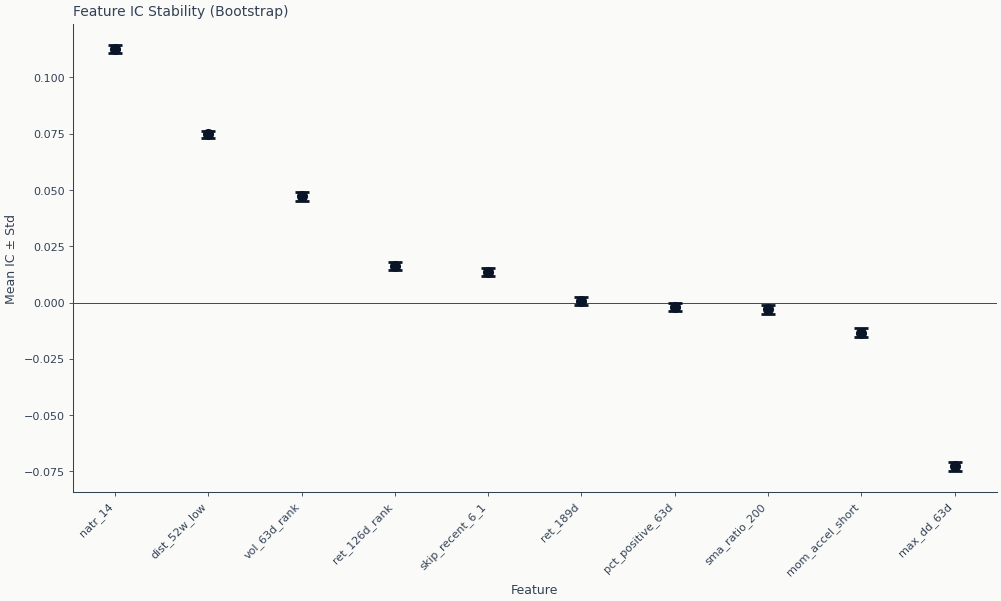

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
stab_pd = stability.to_pandas()
ax.errorbar(
    stab_pd["feature"],
    stab_pd["ic_mean"],
    yerr=stab_pd["ic_std"],
    fmt="o",
    capsize=5,
    capthick=2,
    markersize=8,
)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Feature")
ax.set_ylabel("Mean IC ± Std")
ax.set_title("Feature IC Stability (Bootstrap)")
plt.xticks(rotation=45, ha="right")
plt.show()

## 8. ML-Based Feature Importance

Beyond IC ranking, ML models identify features with non-linear predictive
power. We fit a quick LightGBM model and compare its feature importance
with the IC rankings above.

In [21]:
from ml4t.diagnostic.metrics import analyze_ml_importance

ml_data = analysis.select(["timestamp", "symbol"] + final_features + ["fwd_return_1m"]).drop_nulls()
X = ml_data.select(final_features).to_numpy()
y = ml_data["fwd_return_1m"].to_numpy()

if len(X) > 100:
    from lightgbm import LGBMRegressor

    lgbm = LGBMRegressor(n_estimators=100, max_depth=5, verbose=-1, random_state=SEED)
    lgbm.fit(X, y)

    importance_result = analyze_ml_importance(
        model=lgbm,
        X=X,
        y=y,
        feature_names=final_features,
        methods=["mdi", "pfi"],
    )

    print("=== ML Feature Importance (LightGBM) ===\n")
    print(f"Consensus top features: {importance_result['consensus_ranking'][:10]}")
    print(f"Methods run: {importance_result['methods_run']}")
    if importance_result.get("method_agreement"):
        print(f"Method agreement: {importance_result['method_agreement']}")
    print(f"\n{importance_result['interpretation']}")

=== ML Feature Importance (LightGBM) ===

Consensus top features: ['dist_52w_low', 'natr_14', 'vol_63d_rank', 'ret_189d', 'max_dd_63d', 'skip_recent_6_1', 'ret_126d_rank', 'sma_ratio_200', 'mom_accel_short', 'pct_positive_63d']
Methods run: ['mdi', 'pfi']
Method agreement: {'mdi_vs_pfi': 0.49090909090909085}

Strong consensus: 10 features rank in top 10 across all methods
  Top consensus features: dist_52w_low, natr_14, vol_63d_rank, ret_189d, max_dd_63d
Low agreement between methods (avg correlation: 0.49) - investigate further

Potential Issues:
  - Features {'vol_63d_rank', 'ret_126d_rank'} rank high in MDI but not PFI - possible overfitting to tree structure
  - Low agreement between methods (min correlation: 0.49) - results may be unreliable


**Interpretation**: MDI (Mean Decrease in Impurity) measures how much each
feature reduces prediction error in the tree ensemble. PFI (Permutation
Feature Importance) measures how much shuffling a feature degrades
predictions. Features ranking high in both IC and ML importance are the
strongest candidates for production.

## 9. Post-Selection Verification

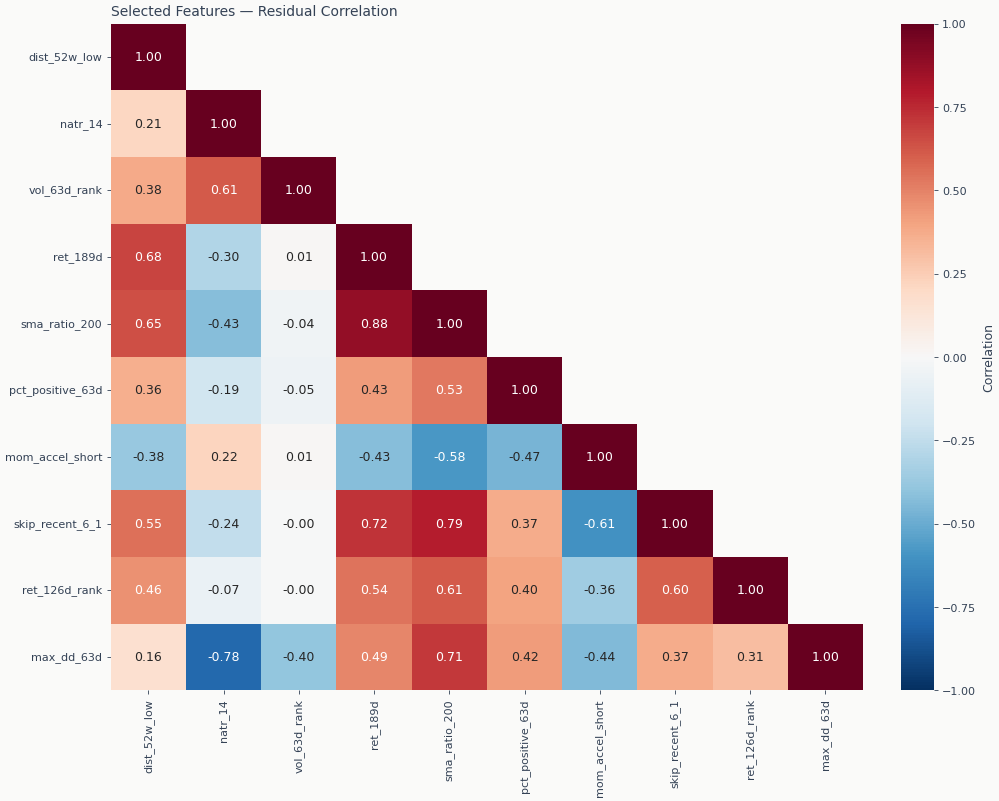

Max remaining correlation: 0.878


In [22]:
# Verify low inter-correlation among selected features
selected_matrix = features_df.select(final_features).drop_nulls()
corr_after = selected_matrix.corr().to_numpy()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_after, dtype=bool), k=1)
sns.heatmap(
    corr_after,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    xticklabels=final_features,
    yticklabels=final_features,
    cbar_kws={"label": "Correlation"},
)
ax.set_title("Selected Features — Residual Correlation")
plt.show()

np.fill_diagonal(corr_after, 0)
max_corr = np.abs(corr_after).max()
print(f"Max remaining correlation: {max_corr:.3f}")

## 10. Selection Summary and Output

In [23]:
print("=" * 60)
print("FEATURE SELECTION REPORT")
print("=" * 60)
print(f"\nInitial Features:           {len(all_feature_cols)}")
print(f"After Correlation Filter:   {len(kept_after_corr)}")
print(f"After IC Filter:            {len(kept_after_ic)}")
print(f"Final Selected:             {len(final_features)}")
print(f"Removal Rate:               {100 * (1 - len(final_features) / len(all_feature_cols)):.1f}%")
print("\n" + "-" * 60)
print("SELECTED FEATURES FOR CHAPTER 9")
print("-" * 60)

for i, f in enumerate(final_features, 1):
    ic = ic_scores[f]
    stab_row = stability.filter(pl.col("feature") == f)
    ic_ir = stab_row["ic_ir"][0] if len(stab_row) > 0 else np.nan
    print(f"{i:2d}. {f:30s} IC={ic:+.4f}  IC_IR={ic_ir:.2f}")

print("=" * 60)

FEATURE SELECTION REPORT

Initial Features:           57
After Correlation Filter:   43
After IC Filter:            18
Final Selected:             10
Removal Rate:               82.5%

------------------------------------------------------------
SELECTED FEATURES FOR CHAPTER 9
------------------------------------------------------------
 1. dist_52w_low                   IC=+0.0764  IC_IR=45.19
 2. natr_14                        IC=+0.0572  IC_IR=62.70
 3. vol_63d_rank                   IC=+0.0509  IC_IR=25.12
 4. ret_189d                       IC=+0.0411  IC_IR=0.34
 5. sma_ratio_200                  IC=+0.0335  IC_IR=-1.68
 6. pct_positive_63d               IC=+0.0294  IC_IR=-1.12
 7. mom_accel_short                IC=-0.0261  IC_IR=-6.91
 8. skip_recent_6_1                IC=+0.0241  IC_IR=7.59
 9. ret_126d_rank                  IC=+0.0234  IC_IR=8.19
10. max_dd_63d                     IC=-0.0203  IC_IR=-34.96


In [24]:
# Save selected features for Chapter 9
OUTPUT_DIR = get_output_dir(8, "feature_selection")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

selected_df = pl.DataFrame(
    {"feature": final_features, "ic": [ic_scores[f] for f in final_features]}
)
selected_df.write_parquet(OUTPUT_DIR / "selected_features.parquet")

filtered_features = features_df.select(["timestamp", "symbol"] + final_features)
filtered_features.write_parquet(OUTPUT_DIR / "features_selected.parquet")

print(f"Saved selected features to {OUTPUT_DIR}")
print(f"  - selected_features.parquet: {len(final_features)} features")
print(f"  - features_selected.parquet: {filtered_features.shape}")

Saved selected features to 08_financial_features/output/feature_selection
  - selected_features.parquet: 10 features
  - features_selected.parquet: (396186, 12)


## Key Takeaways

1. **Cross-sectional IC** is the correct method for factor evaluation —
   pooled IC conflates time-series drift with predictive power
2. **Correlation filtering** (|r| > 0.9) removes obvious redundancy;
   **clustering** catches subtler near-duplicates within feature families
3. **Use average or complete linkage** (not Ward) for correlation distances —
   Ward assumes Euclidean geometry
4. **BH-FDR with HAC-adjusted p-values** controls false discovery when
   screening many candidates. The p-values fed into BH-FDR come from the
   Newey-West t-statistic on each feature's daily IC series, not the
   i.i.d. t-stat, because daily ICs are serially correlated. Without
   multiple-testing correction, ~5% of null features appear significant
   at the 5% level by chance alone
5. **Bootstrap stability** separates features with robust IC from those
   that depend on a few outlier periods
6. Features ranking high in both IC and ML importance are the strongest
   production candidates

**Next**: `06_robustness_sensitivity` — parameter sensitivity and
regime-conditional analysis